In [1]:
!pip install diffusers transformers safetensors accelerate


In [2]:
from PIL import Image

# Cargar imagen directamente desde el entorno de archivos
input_image = Image.open("selfie.png").convert("RGB")

In [3]:
from diffusers import DiffusionPipeline
from google.colab import userdata
import torch

# Usar el token desde secretos
hf_token = userdata.get('HF_TOKEN')


In [4]:
from pipeline import PhotoMakerStableDiffusionXLPipeline

In [5]:
# Cargar modelo base compatible con PhotoMaker
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to("cuda" if torch.cuda.is_available() else "cpu")

# Reemplazar clase base por clase PhotoMaker
pipe.__class__ = PhotoMakerStableDiffusionXLPipeline

# Cargar el adaptador de PhotoMaker
pipe.load_photomaker_adapter(
    pretrained_model_name_or_path_or_dict="TencentARC/PhotoMaker",
    weight_name="photomaker-v1.bin",
    trigger_word="img"
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

photomaker-v1.bin:   0%|          | 0.00/934M [00:00<?, ?B/s]

Loading PhotoMaker components [1] id_encoder from [TencentARC/PhotoMaker]...
Loading PhotoMaker components [2] lora_weights from [TencentARC/PhotoMaker]


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [8]:
# Variable modificable
especialidad = "radiology"  # Cambia esto por la especialidad deseada (e.g., "pediatrician", "cardiologist")

prompt = (
    f"a full-body highly detailed and realistic photo of a young male {especialidad} actively working in a hospital, "
    "such as examining a patient, writing on a chart, or using medical instruments, "
    "flawless face, symmetrical features, clean skin, sharp eyes, natural lighting, professional look, "
    "wearing appropriate medical uniform, DSLR photo, ultra realistic, img"
)

# Negative prompt para evitar estilos no realistas
negative_prompt = (
    "cartoon, anime, illustration, drawing, painting, 3d, cgi, bad anatomy, extra limbs, disfigured face, "
    "blurry, low resolution, distorted eyes, asymmetrical face, skin blemishes, unrealistic skin texture, grainy, jpeg artifacts"
)


result = pipe(
    prompt=prompt,
    input_id_images=input_image,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=5.0
)


# Guardar resultado
result.images[0].save("output.png")

torch.Size([1, 2048]) torch.Size([1, 2048])


  0%|          | 0/30 [00:00<?, ?it/s]

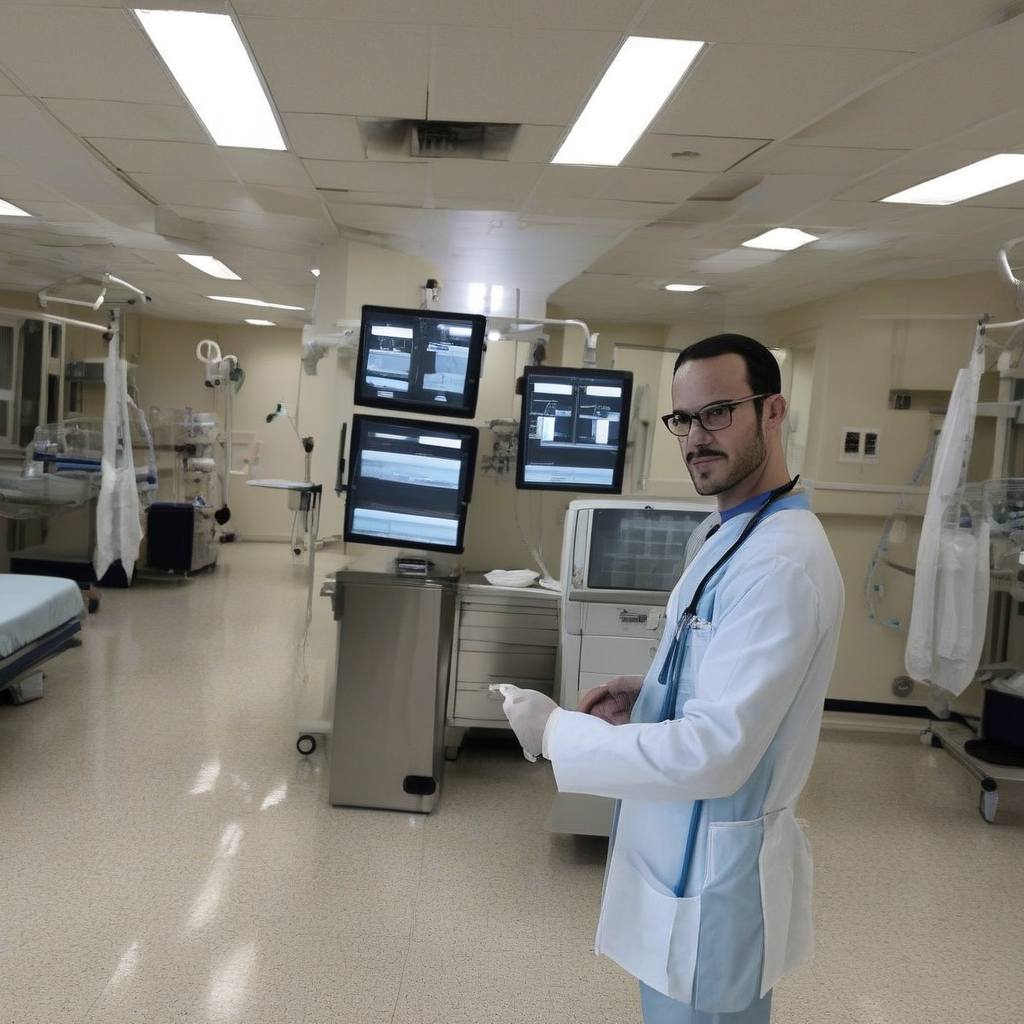

In [9]:
from IPython.display import Image as IPyImage, display

# Mostrar imagen generada
display(IPyImage(filename="output.png"))


In [ ]:
#Liberar memoria si ya no voy a generar imágenes
del pipe
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
